
# SpotifyWave Music Recommender

Welcome to the **SpotifyWave Music Recommender** project! Your team will play the role of a small music‑tech startup designing a simple but insightful prototype for helping people discover songs and playlists that fit their current goals and mood.

This notebook is organised into **5 learning days**. Each day has clear tasks, short instructions, and space for exploration. You don’t need deep math to follow along—focus on understanding the ideas and observing how your design choices change the recommendations.

---

## Introduction to Recommendation Systems

### What is a Recommendation System?

A **recommendation system** is a tool that suggests items to users based on patterns in data. You encounter them every day:

- A streaming platform suggesting **songs** or **playlists**
- A video platform queuing the next **video**
- An online shop recommending **“You may also like…”** items
- A learning platform suggesting **courses** or **articles**

In all of these cases, the system is trying to answer the same question:

> _“Given what I know about this user and this catalog, which few items should I show next?”_

### Two classic approaches

In this project we focus on **content‑based recommendation**, but it helps to know the two classic families:

- **Content‑based filtering**  
  Recommends items that are **similar to items the user already liked**, based on item features.  
  In the music case, features can be things like:
  - valence (how positive the mood is),
  - energy (how intense the track feels),
  - tempo,
  - genre,
  - text descriptions (track title, artist, playlist description).

- **Collaborative filtering**  
  Recommends items that **similar users** liked, without needing explicit features.  
  Example: _“People who liked these tracks also liked…”_.  
  We do **not** implement collaborative filtering here, because for teaching we want a system where we can clearly see and visualise **why** two songs are considered similar.

### How will we build recommendations here?

In this notebook we will:

1. Use a **real Spotify songs dataset** with audio features and metadata.
2. Build **embeddings** for tracks using pretrained models so that similar songs are close together in a numeric space.
3. Simulate a small rating history for your **listener persona**.
4. Compute recommendations based on:
   - similarity to what the persona “liked” in the past,
   - explicit feature goals such as mood (valence), energy, tempo, and popularity.
5. Expose **sliders** so you can steer the behaviour of the recommender and immediately see how the top results change.

---

## 5‑Day Learning Plan (for this notebook)

- **Day 1 – Users & data**  
  Create a listener persona and explore the music dataset and its main features.

- **Day 2 – Embeddings & maps**  
  Turn tracks into embeddings using pretrained models and visualise them in 2D.

- **Day 3 – Base recommender**  
  Simulate ratings for your persona and build a basic similarity‑based recommender.

- **Day 4 – Control knobs**  
  Add sliders for mood, energy, tempo and mainstream‑vs‑niche, and observe how the recommendations and the embedding map change.

- **Day 5 – Reflection & ethics**  
  Analyse how such a system can influence behaviour, discuss ethical and persuasive aspects, and sketch better interface ideas.

### A note on control and ethics

Most real‑world music recommenders do **not** expose this level of control. You typically see a single “smart mix” button with very few adjustable parameters. In this notebook you will see how:

- giving users **transparent control** over features (mood, energy, popularity) can be empowering, but
- the way defaults and sliders are designed can still strongly **nudge** people in certain directions.

Keep this in mind while you work through the tasks.



## Day 1 – Getting to Know the Music Data

On **Day 1** your goal is to understand the problem setting and the raw material your recommender will work with.

You will:

- define a **listener persona** with a concrete goal (e.g. focus, relax, party),
- load a **real Spotify songs dataset**,
- inspect key audio features such as `danceability`, `energy`, `valence`, `tempo`, etc.,
- visualise a sample of songs in the **valence–energy space** to build intuition for what “similarity” could mean in music.

We use a public **TidyTuesday Spotify dataset** that aggregates songs from multiple curated playlists on Spotify. It contains, among others:

- track-level metadata (`track_name`, `track_artist`),
- playlist-level context (`playlist_genre`, `playlist_subgenre`),
- audio features (`danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`, `tempo`),
- a rough popularity indicator (`track_popularity`).

These features will later be combined with **pretrained text embeddings** to build a transparent, content-based music recommender, and then extended with interactive control knobs in Days 4 and 5.



---

## Day 1 – Task Overview

- **Task 1.1** – Create a music listener **persona**
- **Task 1.2** – Load a real Spotify dataset
- **Task 1.3** – Inspect feature columns and distributions
- **Task 1.4** – Visualize songs in a simple **valence–energy** space


## 0. Setup (Run this first)

In [1]:

!pip -q install sentence-transformers umap-learn plotly pandas matplotlib scikit-learn ipywidgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import umap

from sentence_transformers import SentenceTransformer

import ipywidgets as widgets
from IPython.display import display, Audio

# For Colab widget support (safe to ignore elsewhere)
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.2 MB/s eta 0:00:00



## 1. Task 1.1 – Create your listener persona 🎧

Fill in a short description of the person we are designing for.
This is **not** used directly by the algorithm, but it anchors your design thinking.


In [2]:
persona_name = input("Persona name (e.g., 'Focused data scientist'): ")
persona_goal = input("Main goal with music today (e.g., 'deep work', 'relax', 'party'): ")
persona_notes = input("Short description (2–3 sentences): ")

print("\nPersona summary:\n")
print(f"Name: {persona_name or 'N/A'}")
print(f"Goal: {persona_goal or 'N/A'}")
print(f"Notes: {persona_notes or 'N/A'}")


Persona name (e.g., 'Focused data scientist'): Loris, average cross-border banker
Main goal with music today (e.g., 'deep work', 'relax', 'party'): energy
Short description (2–3 sentences): Main goal with music today is getting energized throughout the day Has one kid, going through divorce, always tired, wakes up early, bad diet, late 30s, listens to music in traffic while commuting, wants hands-off playlists, high-BPM but not for dancing, miss his home-town, nostalgic, eurobeat and punk

Persona summary:

Name: Loris, average cross-border banker
Goal: energy
Notes: Main goal with music today is getting energized throughout the day Has one kid, going through divorce, always tired, wakes up early, bad diet, late 30s, listens to music in traffic while commuting, wants hands-off playlists, high-BPM but not for dancing, miss his home-town, nostalgic, eurobeat and punk



## 2. Task 1.2 – Load a real Spotify dataset

We use the **TidyTuesday Spotify songs dataset** (2020-01-21), which aggregates songs from multiple
curated playlists on Spotify. The file is hosted publicly on GitHub.

It contains, among others:

- `track_name`, `track_artist`
- `playlist_genre`, `playlist_subgenre`
- audio features: `danceability`, `energy`, `valence`, `tempo`, `acousticness`, `instrumentalness`, etc.
- `track_popularity` (0–100) – rough measure of how mainstream the song is


In [3]:

import os

csv_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
local_path = "spotify_songs.csv"

if not os.path.exists(local_path):
    import urllib.request
    print("Downloading Spotify dataset...")
    urllib.request.urlretrieve(csv_url, local_path)

spotify_df = pd.read_csv(local_path)
spotify_df.head()


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


### Basic info about the dataset

In [4]:

print("Shape:", spotify_df.shape)
print("\nColumns:", list(spotify_df.columns))

spotify_df[["track_name", "track_artist", "playlist_genre", "playlist_subgenre"]].head(10)


Shape: (32833, 23)

Columns: ['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


,track_name,track_artist,playlist_genre,playlist_subgenre
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,pop,dance pop
1,Memories - Dillon Francis Remix,Maroon 5,pop,dance pop
2,All the Time - Don Diablo Remix,Zara Larsson,pop,dance pop
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,pop,dance pop
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,pop,dance pop
5,Beautiful People (feat. Khalid) - Jack Wins Remix,Ed Sheeran,pop,dance pop
6,Never Really Over - R3HAB Remix,Katy Perry,pop,dance pop
7,Post Malone (feat. RANI) - GATTÜSO Remix,Sam Feldt,pop,dance pop
8,Tough Love - Tiësto Remix / Radio Edit,Avicii,pop,dance pop
9,If I Can't Have You - Gryffin Remix,Shawn Mendes,pop,dance pop


In [5]:

feature_cols = [
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "liveness", "speechiness", "tempo"
]

print("Audio feature summary:")
spotify_df[feature_cols + ["track_popularity"]].describe()


Audio feature summary:


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,track_popularity
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,0.654850,0.698619,0.510561,0.175334,0.084747,0.190176,0.107068,120.881132,42.477081
std,0.145085,0.180910,0.233146,0.219633,0.224230,0.154317,0.101314,26.903624,24.984074
min,0.000000,0.000175,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.563000,0.581000,0.331000,0.015100,0.000000,0.092700,0.041000,99.960000,24.000000
50%,0.672000,0.721000,0.512000,0.080400,0.000016,0.127000,0.062500,121.984000,45.000000
75%,0.761000,0.840000,0.693000,0.255000,0.004830,0.248000,0.132000,133.918000,62.000000
max,0.983000,1.000000,0.991000,0.994000,0.994000,0.996000,0.918000,239.440000,100.000000



## 3. Task 1.3 – Visualizing the valence–energy space

Two intuitive features are:

- **Valence** – how positive / happy the track feels (0 = negative, 1 = very positive)
- **Energy** – how intense / energetic the track feels

Below you see a scatter plot of a random sample of tracks in this 2D space.
Color = playlist genre.

> **Question for students:**  
> What kinds of music would you expect in the _high valence, high energy_ corner?


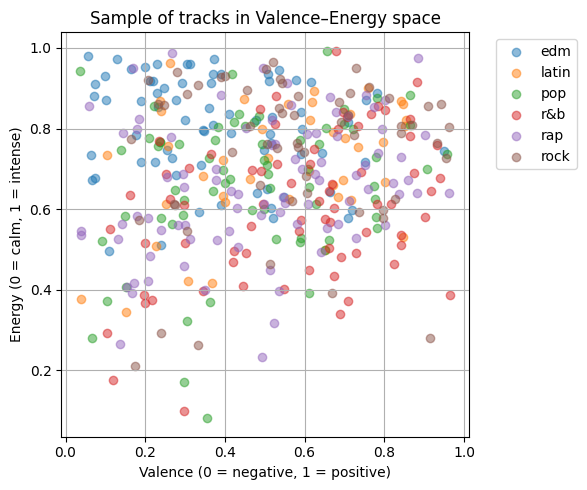

In [6]:

sample_df = spotify_df.sample(400, random_state=42)  # subset for plotting

plt.figure(figsize=(6, 5))
for g, group in sample_df.groupby("playlist_genre"):
    plt.scatter(group["valence"], group["energy"], alpha=0.5, label=g)
plt.xlabel("Valence (0 = negative, 1 = positive)")
plt.ylabel("Energy (0 = calm, 1 = intense)")
plt.title("Sample of tracks in Valence–Energy space")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



---

## Day 2 – From Features to Embeddings & Recommendations

> _Goal_: Learn how to go from raw features and text to an **embedding space**,
build a simple user profile, and generate basic content-based recommendations.



### 4. Task 2.1 – Pretrained text embeddings for tracks

Instead of engineering all features by hand, we can use a **pretrained model** to embed
text about each song into a numeric vector (an **embedding**).

We will use:

- `SentenceTransformer('all-MiniLM-L6-v2')`

For each track we build a short description like:

> `"Shape of You by Ed Sheeran. Genre: pop, subgenre: pop."`

The model converts each description to a vector in a high-dimensional space (~384 dimensions).
Songs that are semantically similar (artist, title, genre) end up **close together**.


In [7]:

# To keep runtimes reasonable in class, we work on a subset
work_df = spotify_df.sample(3000, random_state=123).reset_index(drop=True)

def build_text(row):
    return (
        f"{row['track_name']} by {row['track_artist']}. "
        f"Genre: {row['playlist_genre']}, subgenre: {row['playlist_subgenre']}."
    )

work_df["text"] = work_df.apply(build_text, axis=1)

print("Example descriptions:")

work_df["text"].head()


Example descriptions:


,text
0,"Fuck It Up by Jay Portal. Genre: rap, subgenre..."
1,"Clocks by Coldplay. Genre: pop, subgenre: elec..."
2,"Kein Wort by Juju. Genre: rap, subgenre: hip hop."
3,"How's This by HyunA. Genre: edm, subgenre: pop..."
4,You're My Heart You're My Soul by Laura Tain. ...


In [8]:

print("Loading SentenceTransformer model (this may take ~10–20 seconds)...")
text_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

text_embeddings = text_model.encode(
    work_df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

text_embeddings.shape


Loading SentenceTransformer model (this may take ~10–20 seconds)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

(3000, 384)


### 5. Task 2.2 – Visualizing the embedding space with UMAP

The embeddings are high-dimensional. We use **UMAP** to project them to 2D so we can see
clusters of songs.


In [10]:
scaler = StandardScaler()
X_num = scaler.fit_transform(work_df[feature_cols])

# We concatenate numeric audio features and text embeddings
combined_features = np.hstack([X_num, text_embeddings])

reducer = umap.UMAP(random_state=42, n_neighbors=25, min_dist=0.1)
embedding_2d = reducer.fit_transform(combined_features)

work_df["emb_x"] = embedding_2d[:, 0]
work_df["emb_y"] = embedding_2d[:, 1]

# Calculate medians for categorization
valence_median = work_df["valence"].median()
energy_median = work_df["energy"].median()

# Define specific thresholds for 'high' and 'medium' relative to medians
VALENCE_HIGH_THRESHOLD = valence_median + 0.15 # e.g., 0.15 above median for 'high'
VALENCE_MEDIUM_LOWER = valence_median - 0.15 # e.g., +/- 0.15 around median for 'medium'
VALENCE_MEDIUM_UPPER = valence_median + 0.15
ENERGY_HIGH_THRESHOLD = energy_median # Simply above median for 'high' energy

work_df["highlight_category"] = "Other Tracks"

# High Energy, High Valence Persona
work_df.loc[
    (work_df["energy"] >= ENERGY_HIGH_THRESHOLD) &
    (work_df["valence"] >= VALENCE_HIGH_THRESHOLD),
    "highlight_category"
] = "High Energy, High Valence"

# High Energy, Medium Valence Persona
# Ensure no overlap with 'High Valence' category if a track also meets 'High Valence' criteria
work_df.loc[
    (work_df["energy"] >= ENERGY_HIGH_THRESHOLD) &
    (work_df["valence"] >= VALENCE_MEDIUM_LOWER) &
    (work_df["valence"] < VALENCE_MEDIUM_UPPER),
    "highlight_category"
] = "High Energy, Medium Valence"

# Normalize tempo and loudness for Plot 2
work_df['tempo_norm'] = (work_df['tempo'] - work_df['tempo'].min()) / (work_df['tempo'].max() - work_df['tempo'].min() + 1e-8)
work_df['loudness_norm'] = (work_df['loudness'] - work_df['loudness'].min()) / (work_df['loudness'].max() - work_df['loudness'].min() + 1e-8)
work_df['tempo_loudness_score'] = (work_df['tempo_norm'] + work_df['loudness_norm']) / 2


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [11]:
# Plot 1: High Energy, Medium Valence songs in dark blue, others gray
color_map_plot1 = {
    "High Energy, High Valence": "lightgray", # Not directly highlighted in this plot, so gray
    "High Energy, Medium Valence": "darkblue",
    "Other Tracks": "lightgray"
}

fig1 = px.scatter(
    work_df,
    x="emb_x", y="emb_y",
    color="highlight_category", # Use the new categorical column for coloring
    color_discrete_map=color_map_plot1, # Apply the custom color map
    hover_data=["track_name", "track_artist", "playlist_subgenre", "tempo", "valence", "energy"],
    title="2D embedding: High Energy, Medium Valence Tracks (Dark Blue)"
)
fig1.show()

In [12]:
# Plot 2: High Tempo & High Loudness within the 'blue' songs from Plot 1

# Prepare data for the second plot: color 'High Energy, Medium Valence' by tempo_loudness_score,
# and other tracks as light gray for context.
plot2_df = work_df.copy()
plot2_df.loc[plot2_df['highlight_category'] != 'High Energy, Medium Valence', 'tempo_loudness_score'] = None # Set others to None for gradient effect

fig2 = px.scatter(
    plot2_df,
    x="emb_x", y="emb_y",
    color="tempo_loudness_score", # Color only 'High Energy, Medium Valence' tracks by this score
    color_continuous_scale=px.colors.sequential.Plasma, # Choose a suitable gradient for tempo/loudness
    color_continuous_midpoint=plot2_df['tempo_loudness_score'].median(), # Center the color scale
    hover_data=["track_name", "track_artist", "playlist_subgenre", "tempo", "loudness", "tempo_loudness_score", "valence", "energy"],
    title="2D embedding: High Energy, Medium Valence Tracks colored by Tempo & Loudness"
)

# Ensure non-highlighted tracks are still visible in gray for context if they weren't in plot2_df originally
fig2.add_trace(px.scatter(
    work_df[work_df['highlight_category'] != 'High Energy, Medium Valence'],
    x="emb_x", y="emb_y",
    color_discrete_sequence=['lightgray'], # Explicitly set color for 'Other Tracks'
    hover_data=["track_name", "track_artist", "playlist_subgenre", "tempo", "loudness", "valence", "energy"]
).data[0])

fig2.show()

In [13]:
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import umap


# === 1. Scale numeric features ===
scaler = StandardScaler()
X_num = scaler.fit_transform(work_df[feature_cols])

# === 2. Concatenate numeric + text embeddings ===
combined_features = np.hstack([X_num, text_embeddings])

# === 3. 3D UMAP ===
reducer = umap.UMAP(
    random_state=42,
    n_neighbors=25,
    min_dist=0.1,
    n_components=3,     # <-- IMPORTANT
)
embedding_3d = reducer.fit_transform(combined_features)

# Save to dataframe
work_df["emb_x"] = embedding_3d[:, 0]
work_df["emb_y"] = embedding_3d[:, 1]
work_df["emb_z"] = embedding_3d[:, 2]

# === 4. 3D scatter plot ===
fig = px.scatter_3d(
    work_df,
    x="emb_x",
    y="emb_y",
    z="emb_z",
    color="playlist_genre",
    hover_data=["track_name", "track_artist", "playlist_subgenre"],
    title="3D embedding of tracks (text + audio features)"
)

fig.update_traces(marker=dict(size=4))  # optional tweak

fig.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [14]:
import plotly.express as px

# Prepare data for the 3D plot, similar to plot2_df
plot3d_df = work_df.copy()
plot3d_df.loc[plot3d_df['highlight_category'] != 'High Energy, Medium Valence', 'tempo_loudness_score'] = None # Set others to None for gradient effect

fig3 = px.scatter_3d(
    plot3d_df,
    x="emb_x", y="emb_y", z="emb_z",
    color="tempo_loudness_score", # Color only 'High Energy, Medium Valence' tracks by this score
    color_continuous_scale=px.colors.sequential.Plasma, # Use the same gradient as Plot 2
    color_continuous_midpoint=plot3d_df['tempo_loudness_score'].median(), # Center the color scale
    hover_data=["track_name", "track_artist", "playlist_subgenre", "tempo", "loudness", "tempo_loudness_score", "valence", "energy"],
    title="3D Embedding: High Energy, Medium Valence Tracks colored by Tempo & Loudness"
)

# Add non-highlighted tracks in gray for context
fig3.add_trace(px.scatter_3d(
    work_df[work_df['highlight_category'] != 'High Energy, Medium Valence'],
    x="emb_x", y="emb_y", z="emb_z",
    color_discrete_sequence=['lightgray'], # Explicitly set color for 'Other Tracks'
    hover_data=["track_name", "track_artist", "playlist_subgenre", "tempo", "loudness", "valence", "energy"]
).data[0])

fig3.update_traces(marker=dict(size=3)) # Optional: Adjust marker size for better visualization
fig3.show()


**How to read this plot:**

- Each point = one track.
- Distance in this 2D plot approximates **similarity** in the high-dimensional embedding.
- Tracks with similar artist/genre/playlist context tend to cluster together.
- Colors show `playlist_genre` – clusters often become genre-ish regions, but not perfectly.

> **Discussion prompt:**  
> Does your intuition about which genres are similar match what you see here?



### 6. Task 2.3 – Simulated ratings for your persona

To avoid asking you to rate 100+ tracks, we simulate a rating history consistent
with your persona goal.

We use a very simple mapping:

- If `persona_goal` mentions _chill, focus, study_ → favour genres like `chill`, `study`, `soft`…
- If it mentions _party, dance_ → favour higher energy playlists.
- Otherwise we just pick a default.

This is obviously **not realistic**, but sufficient to drive the recommender.


In [15]:

goal = (persona_goal or "").lower()

if any(k in goal for k in ["focus", "study", "work", "deep"]):
    preferred_genres = ["study", "chill", "pop"]
elif any(k in goal for k in ["relax", "calm", "sleep"]):
    preferred_genres = ["chill", "r&b"]
elif any(k in goal for k in ["party", "dance", "club"]):
    preferred_genres = ["edm", "latin", "pop"]
else:
    preferred_genres = ["pop", "rock"]

print("Preferred playlist genres for this persona:", preferred_genres)

n_rated = 60
rated_idx = np.random.choice(work_df.index, size=n_rated, replace=False)
rated_df = work_df.loc[rated_idx].copy()

base_rating = 3.0
rated_df["rating"] = base_rating

is_pref = rated_df["playlist_genre"].isin(preferred_genres)
rated_df.loc[is_pref, "rating"] += np.random.uniform(0.5, 2.0, size=is_pref.sum())
rated_df.loc[~is_pref, "rating"] -= np.random.uniform(0.0, 2.0, size=(~is_pref).sum())

rated_df["rating"] += 0.4 * (rated_df["valence"] - 0.5)
rated_df["rating"] = rated_df["rating"].clip(1, 5)

rated_df.sort_values("rating", ascending=False).head(10)[
    ["track_name", "track_artist", "playlist_genre", "valence", "energy", "rating"]
]


Preferred playlist genres for this persona: ['pop', 'rock']


,track_name,track_artist,playlist_genre,valence,energy,rating
174,Hate To Say I Told You So,The Hives,rock,0.390,0.900,4.934847
2303,Breathe,Michelle Branch,pop,0.209,0.753,4.846105
989,So Predictable,Set It Off,pop,0.505,0.867,4.823234
2398,Bitter Sweet Symphony,The Verve,rock,0.518,0.917,4.743890
337,Hyena,Jamshied Sharifi,rock,0.753,0.474,4.689006
2218,Romeo and Juliet,Dire Straits,rock,0.486,0.574,4.668065
2647,I Want It That Way,Backstreet Boys,pop,0.484,0.702,4.656517
2109,Heavy Heavy Heavy,Geraldo Pino,rock,0.866,0.868,4.514544
2653,Pretty Girls,Michael Seyer,rock,0.185,0.402,4.452472
427,I Sat By The Ocean,Queens of the Stone Age,rock,0.897,0.781,4.355854


#### Rating distribution

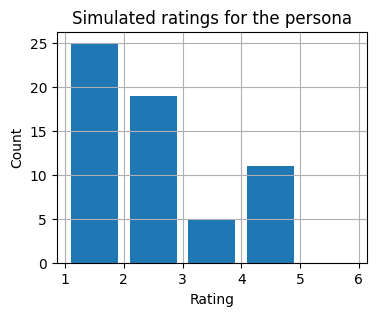

In [16]:

plt.figure(figsize=(4,3))
plt.hist(rated_df["rating"], bins=[1,2,3,4,5,6], rwidth=0.8)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Simulated ratings for the persona")
plt.show()



### 7. Task 2.4 – Base content-based recommender

We now build a **user embedding** by averaging the embeddings of liked songs (rating ≥ 4).\
Then we compute **cosine similarity** to all tracks in the working set.

This gives us a **similarity score** purely based on content (audio + text).


In [17]:

liked_df = rated_df[rated_df["rating"] >= 4]
print("Number of liked tracks:", len(liked_df))

liked_indices = liked_df.index.values
user_vec = combined_features[liked_indices].mean(axis=0, keepdims=True)

all_sims = cosine_similarity(user_vec, combined_features)[0]
work_df["base_sim"] = all_sims

work_df[["track_name", "track_artist", "playlist_genre", "base_sim"]].head()


Number of liked tracks: 11


,track_name,track_artist,playlist_genre,base_sim
0,Fuck It Up,Jay Portal,rap,-0.046376
1,Clocks,Coldplay,pop,0.427458
2,Kein Wort,Juju,rap,0.217706
3,How's This,HyunA,edm,0.190972
4,You're My Heart You're My Soul,Laura Tain,pop,0.317123



---

## Day 3 – Interactive Controls & Ethical Reflection

> _Goal_: Give users control over **how** the recommender behaves using feature-based sliders,
and understand the implications of these design choices.



### 8. Task 3.1 – Feature-based control knobs (sliders)

Instead of abstract “diversity” or “serendipity” scores, we expose **concrete feature controls**:

- Desired **mood brightness** (`target_valence`)
- Desired **energy level** (`target_energy`)
- Desired **tempo range** (`target_tempo`)
- Preference for **mainstream vs niche** (popularity)
- Weight of **embedding similarity** vs these explicit goals

You can think of this as designing a **transparent control panel** for the recommender.


In [18]:

valence_slider = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.05,
    description="Target valence", continuous_update=False
)
energy_slider = widgets.FloatSlider(
    value=0.85, min=0.0, max=1.0, step=0.05,
    description="Target energy", continuous_update=False
)
tempo_slider = widgets.IntSlider(
    value=140, min=60, max=200, step=5,
    description="Target tempo", continuous_update=False
)
pop_slider = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.05,
    description="Mainstream", continuous_update=False
)
sim_slider = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.05,
    description="History match", continuous_update=False
)

def compute_recommendations(target_valence, target_energy, target_tempo,
                             mainstream_pref, history_weight, top_k=12):
    # normalize popularity
    pop = work_df["track_popularity"].fillna(0)
    pop_norm = (pop - pop.min()) / (pop.max() - pop.min() + 1e-8)

    # feature distance penalties
    v_pen = - (work_df["valence"] - target_valence) ** 2
    e_pen = - (work_df["energy"] - target_energy) ** 2
    t_pen = - ((work_df["tempo"] - target_tempo) / 40.0) ** 2  # tempo tolerance

    # popularity vs niche: mainstream_pref close to 1 → reward popularity, 0 → reward niche
    pop_score = mainstream_pref * pop_norm + (1 - mainstream_pref) * (1 - pop_norm)

    # combine
    history_sim = work_df["base_sim"].values
    feature_score = v_pen + e_pen + t_pen + pop_score

    alpha = history_weight
    combined_score = alpha * history_sim + (1 - alpha) * feature_score

    work_df["final_score"] = combined_score

    rated_ids = set(rated_df["track_name"])
    recs = work_df[~work_df["track_name"].isin(rated_ids)].sort_values("final_score", ascending=False).head(top_k)
    return recs

def update_recs(target_valence, target_energy, target_tempo, mainstream, history_match):
    recs = compute_recommendations(target_valence, target_energy, target_tempo,
                                   mainstream, history_match, top_k=12)
    display(recs[[
        "track_name", "track_artist", "playlist_genre",
        "valence", "energy", "tempo", "track_popularity", "final_score"
    ]])

    # visualize in embedding space
    rec_mask = work_df["track_name"].isin(recs["track_name"])
    rated_mask = work_df.index.isin(rated_df.index)

    plt.figure(figsize=(7, 6))
    plt.scatter(work_df.loc[~rec_mask & ~rated_mask, "emb_x"],
                work_df.loc[~rec_mask & ~rated_mask, "emb_y"],
                alpha=0.15, label="Other tracks")
    plt.scatter(work_df.loc[rated_mask, "emb_x"],
                work_df.loc[rated_mask, "emb_y"],
                marker="x", s=40, label="Rated history")
    plt.scatter(work_df.loc[rec_mask, "emb_x"],
                work_df.loc[rec_mask, "emb_y"],
                s=90, label="Recommended now")
    plt.title("Embedding space: history vs current recommendations")
    plt.xlabel("emb_x"); plt.ylabel("emb_y")
    plt.legend()
    plt.grid(True)
    plt.show()

controls = widgets.VBox([valence_slider, energy_slider, tempo_slider, pop_slider, sim_slider])
output = widgets.interactive_output(
    update_recs,
    {
        "target_valence": valence_slider,
        "target_energy": energy_slider,
        "target_tempo": tempo_slider,
        "mainstream": pop_slider,
        "history_match": sim_slider,
    }
)

display(controls, output)


Output()


**How to read the output table:**

- `valence`, `energy`, `tempo` – do they align with your slider choices?
- `track_popularity` – how mainstream are the recommendations?
- `final_score` – overall score combining history similarity + feature fit (higher is better).

**How to read the embedding plot:**

- Crosses (×) = songs in the simulated **rating history**.
- Circles highlighted as “Recommended now” = songs your current slider settings put on top.
- Faded points = all other candidates.

> Try different combinations and see when the recommendations **stop matching** the persona’s intent.



### 9. Optional – Play a demo audio snippet

This is **not** the actual Spotify track (for licensing reasons), but a generic sample
so you can at least try out the audio block in Colab.

Pick any recommended track row above and enter its row index (0–11).


In [20]:

demo_urls = [
    "https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3",
    "https://www.soundhelix.com/examples/mp3/SoundHelix-Song-2.mp3",
    "https://www.soundhelix.com/examples/mp3/SoundHelix-Song-3.mp3",
]

try:
    row_idx = int(input("Enter recommended row index (0–11) to play demo audio (or -1 to skip): "))
except ValueError:
    row_idx = -1

if 0 <= row_idx < 12:
    url = demo_urls[row_idx % len(demo_urls)]
    print(f"Playing generic preview clip: {url}")
    display(Audio(url))
else:
    print("No audio selected.")


Enter recommended row index (0–11) to play demo audio (or -1 to skip): -1
No audio selected.


In [21]:
# ============================================
# Persona Input + Recommendation UI (Final Cell)
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML

# --- Persona Free-Text Fields ---
persona_name = widgets.Text(
    value='',
    placeholder='e.g., Sofia the Calm Analyst',
    description='Persona:',
    layout=widgets.Layout(width='60%')
)

persona_traits = widgets.Textarea(
    value='',
    placeholder='Describe key traits, goals, moods, lifestyle...',
    description='Traits:',
    layout=widgets.Layout(width='60%', height='80px')
)

persona_music = widgets.Text(
    value='',
    placeholder='e.g., calm piano, deep house, classic rock',
    description='Likes:',
    layout=widgets.Layout(width='60%')
)

persona_moods = widgets.Text(
    value='',
    placeholder='e.g., chill, energetic in the morning...',
    description='Moods:',
    layout=widgets.Layout(width='60%')
)

# ------------------------------------
# Existing Target Sliders (Preferences)
# ------------------------------------
valence_slider = widgets.FloatSlider(
    value=0.6, min=0.0, max=1.0, step=0.05,
    description="Target valence", continuous_update=False
)
energy_slider = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.05,
    description="Target energy", continuous_update=False
)
tempo_slider = widgets.IntSlider(
    value=120, min=60, max=200, step=5,
    description="Target tempo", continuous_update=False
)
pop_slider = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.05,
    description="Mainstream", continuous_update=False
)
sim_slider = widgets.FloatSlider(
    value=0.6, min=0.0, max=1.0, step=0.05,
    description="History match", continuous_update=False
)

# ------------------------------------
# Display persona summary (optional)
# ------------------------------------
def show_persona_summary(_):
    display(HTML(f"""
    <h3>🎭 Persona Summary</h3>
    <ul>
        <li><b>Name:</b> {persona_name.value}</li>
        <li><b>Traits:</b> {persona_traits.value}</li>
        <li><b>Music Tastes:</b> {persona_music.value}</li>
        <li><b>Mood Patterns:</b> {persona_moods.value}</li>
    </ul>
    <p>Recommendations below are generated based on the sliders + persona intent.</p>
    """))

summary_button = widgets.Button(description="Show Persona Summary", button_style="", icon="user")
summary_button.on_click(show_persona_summary)

# ------------------------------------
# Recommendation UI (direct compute)
# ------------------------------------
def update_recs(target_valence, target_energy, target_tempo, mainstream, history_match):
    recs = compute_recommendations(
        target_valence, target_energy, target_tempo,
        mainstream, history_match, top_k=12
    )

    display(HTML("<h3>🎧 Recommendations for Persona</h3>"))
    display(recs[[
        "track_name", "track_artist", "playlist_genre",
        "valence", "energy", "tempo", "track_popularity", "final_score"
    ]])

    # Embedding plot
    rec_mask = work_df["track_name"].isin(recs["track_name"])
    rated_mask = work_df.index.isin(rated_df.index)

    plt.figure(figsize=(7, 6))
    plt.scatter(work_df.loc[~rec_mask & ~rated_mask, "emb_x"],
                work_df.loc[~rec_mask & ~rated_mask, "emb_y"],
                alpha=0.15, label="Other tracks")
    plt.scatter(work_df.loc[rated_mask, "emb_x"],
                work_df.loc[rated_mask, "emb_y"],
                marker="x", s=40, label="Rated history")
    plt.scatter(work_df.loc[rec_mask, "emb_x"],
                work_df.loc[rec_mask, "emb_y"],
                s=90, label="Recommended now")
    plt.title(f"Embedding space – Recommendations for {persona_name.value}")
    plt.xlabel("emb_x"); plt.ylabel("emb_y")
    plt.legend()
    plt.grid(True)
    plt.show()

controls = widgets.VBox([
    persona_name,
    persona_traits,
    persona_music,
    persona_moods,
    summary_button,
    valence_slider, energy_slider, tempo_slider, pop_slider, sim_slider
])

output = widgets.interactive_output(
    update_recs,
    {
        "target_valence": valence_slider,
        "target_energy": energy_slider,
        "target_tempo": tempo_slider,
        "mainstream": pop_slider,
        "history_match": sim_slider,
    }
)

display(controls, output)


Output()


---

## 10. Ethical & Persuasive Aspects – Reflection Notes

Use this as lecture-style notes and for group discussion.

### 10.1 Feature controls as **subtle persuasion**

- Even though we expose meaningful sliders (mood, energy, mainstream), the **default values**
  act as a strong nudge.
- If the default always leans towards high `track_popularity`, the system will continually
  promote mainstream music and **suppress niche artists**.
- The persona might want “calm focus music”, but if `mainstream` is high by default, they may
  be pushed towards popular pop ballads instead of experimental ambient tracks.

### 10.2 Matching the persona vs optimising engagement

- Our scoring combines **history similarity** and **current mood sliders**.  
  A real platform might add another hidden term: expected **engagement / retention / ad revenue**.
- This can lead to **goal misalignment**:
  - User’s goal: focus, relax, recover.
  - Platform’s goal: maximise listening time or ad impressions.
- From the outside, everything looks like a harmless “smart playlist”. Internally, weights
  might be tuned to drive behaviour in a particular direction.

### 10.3 Transparency and control

- By exposing concrete features (`valence`, `energy`, `tempo`, `popularity`) instead of abstract
  “smartness”, users can **reason** about why they get certain songs.
- However, many real apps do **not** expose such controls, or they hide them deep in menus.
- Good questions for designers:
  - Which controls should be **exposed** to users?
  - Which should remain internal?
  - How do we communicate the effects of these knobs in understandable language?

### 10.4 What to try as a group

1. Change the persona text (e.g., from “party mode” to “burnt-out student needing calm focus”).  
2. Re-run the notebook to simulate new ratings.  
3. Play with sliders and **check the top 10 recommendations**:
   - Do they actually match the persona’s needs?
   - Do you see unwanted biases (e.g., always certain genres)?
4. Discuss how you might redesign the interface or scoring to better respect user goals.


In [22]:
# ============================================================================================
# 🎧 Persona-Based Rating (with audio) + Preference Sliders + Final Recommendations (ALL-IN-ONE)
# ============================================================================================

import ipywidgets as widgets
from IPython.display import display, HTML, Audio
import pandas as pd
import random

display(HTML("<h2>🎭 Persona Music Preference Simulator</h2>"))
display(HTML("<p>Listen to songs → Rate them → Adjust sliders → See recommendations</p>"))

# ------------------------------------------------------------------
# 1) PERSONA INFO
# ------------------------------------------------------------------
persona_name = widgets.Text(
    value='',
    placeholder='e.g., Calm Introvert Sofia',
    description='Persona:',
    layout=widgets.Layout(width='60%')
)

persona_traits = widgets.Textarea(
    value='',
    placeholder='Describe the persona’s mood, habits, taste...',
    description='Traits:',
    layout=widgets.Layout(width='60%', height='70px')
)

display(persona_name, persona_traits)

# ------------------------------------------------------------------
# 2) SAMPLE 10 TRACKS + RANDOM AUDIO PREVIEW
# ------------------------------------------------------------------

display(HTML("<h3>🎧 Step 1 — Listen & Rate the Following Tracks</h3>"))

# Free, open, no-login audio pool
soundhelix_pool = [
    f"https://www.soundhelix.com/examples/mp3/SoundHelix-Song-{i}.mp3"
    for i in range(1, 17)
]

# sample 10 tracks
sample_df = work_df.sample(10, random_state=42).reset_index(drop=True)

rating_widgets = []
audio_used = []

for idx, row in sample_df.iterrows():

    audio_url = random.choice(soundhelix_pool)
    audio_used.append(audio_url)

    # show track name
    display(HTML(f"<b>{row['track_name']} – {row['track_artist']}</b>"))

    # audio player
    display(Audio(url=audio_url, autoplay=False))

    # rating slider
    slider = widgets.IntSlider(
        value=3, min=1, max=5, step=1,
        description="Rating:",
        continuous_update=False,
        layout=widgets.Layout(width='50%')
    )
    rating_widgets.append(slider)
    display(slider)

# ------------------------------------------------------------------
# 3) SAVE RATINGS → rated_df
# ------------------------------------------------------------------

save_button = widgets.Button(
    description="💾 Save Persona Ratings",
    button_style="success",
    icon="check"
)

ratings_output = widgets.Output()

def save_persona_ratings(_):
    global rated_df

    persona_ratings = []
    for widget, (_, row), audio_url in zip(rating_widgets, sample_df.iterrows(), audio_used):
        persona_ratings.append({
            "persona": persona_name.value,
            "track_name": row["track_name"],
            "track_artist": row["track_artist"],
            "rating": widget.value,
            "audio_preview": audio_url
        })

    persona_rating_df = pd.DataFrame(persona_ratings)

    # merge with rated_df if exists
    try:
        rated_df = pd.concat([rated_df, persona_rating_df], ignore_index=True)
        rated_df = rated_df.drop_duplicates(subset=["track_name", "track_artist"], keep="last")
    except:
        rated_df = persona_rating_df

    with ratings_output:
        ratings_output.clear_output()
        display(HTML("<b>✔ Persona ratings saved!</b>"))
        display(rated_df.head())

save_button.on_click(save_persona_ratings)

display(save_button, ratings_output)

# ------------------------------------------------------------------
# 4) SLIDERS THAT AFFECT THE RECOMMENDER
# ------------------------------------------------------------------

display(HTML("<h3>🎚 Step 2 — Adjust Preference Sliders</h3>"))

valence_slider = widgets.FloatSlider(
    value=0.6, min=0.0, max=1.0, step=0.05,
    description="Valence",
    continuous_update=False
)
energy_slider = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.05,
    description="Energy",
    continuous_update=False
)
tempo_slider = widgets.IntSlider(
    value=120, min=60, max=200, step=5,
    description="Tempo",
    continuous_update=False
)
pop_slider = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.05,
    description="Mainstream",
    continuous_update=False
)
sim_slider = widgets.FloatSlider(
    value=0.6, min=0.0, max=1.0, step=0.05,
    description="History",
    continuous_update=False
)

controls = widgets.VBox([
    valence_slider,
    energy_slider,
    tempo_slider,
    pop_slider,
    sim_slider
])

# ------------------------------------------------------------------
# 5) FINAL RECOMMENDATIONS (calls update_recs)
# ------------------------------------------------------------------

display(HTML("<h3>🎵 Step 3 — View Final Recommendations</h3>"))

output = widgets.interactive_output(
    update_recs,
    {
        "target_valence": valence_slider,
        "target_energy": energy_slider,
        "target_tempo": tempo_slider,
        "mainstream": pop_slider,
        "history_match": sim_slider,
    }
)

display(controls, output)


Text(value='', description='Persona:', layout=Layout(width='60%'), placeholder='e.g., Calm Introvert Sofia')

Textarea(value='', description='Traits:', layout=Layout(height='70px', width='60%'), placeholder='Describe the…

IntSlider(value=3, continuous_update=False, description='Rating:', layout=Layout(width='50%'), max=5, min=1)

IntSlider(value=3, continuous_update=False, description='Rating:', layout=Layout(width='50%'), max=5, min=1)

IntSlider(value=3, continuous_update=False, description='Rating:', layout=Layout(width='50%'), max=5, min=1)

...

IntSlider(value=3, continuous_update=False, description='Rating:', layout=Layout(width='50%'), max=5, min=1)

IntSlider(value=3, continuous_update=False, description='Rating:', layout=Layout(width='50%'), max=5, min=1)

Button(button_style='success', description='💾 Save Persona Ratings', icon='check', style=ButtonStyle())

Output()

Output()